# **1. Seq2Seq**

시퀀스투시퀀스(Sequence-to-Sequence, Seq2Seq) 모델은 입력 시퀀스를 받아 출력 시퀀스를 생성하는 신경망 아키텍처로, 주로 자연어 처리 분야에서 번역, 요약, 질의응답 등에 활용됩니다. Seq2Seq 모델은 일반적으로 인코더(Encoder)와 디코더(Decoder) 두 부분으로 구성되며, 인코더는 입력 문장을 고정된 크기의 컨텍스트 벡터로 변환하고, 디코더는 이를 기반으로 출력 문장을 생성합니다. RNN, LSTM, GRU 등의 순환 신경망을 활용하며, 최근에는 어텐션 메커니즘과 트랜스포머 모델이 도입되어 더 긴 문맥을 효과적으로 처리할 수 있게 되었습니다. [[논문](https://arxiv.org/pdf/1409.3215)]

- Seq2Seq는 입력 시퀀스를 받아 다른 출력 시퀀스로 바꾸는 구조
- 대표적인 예는 기계 번역
    - I love coffee > 나는 커피를 좋아해
    - I love coffee > Encoder > 문장 정보 압축 > Decoder > \<BOS\>나는 / 커피를 / 좋아해 \<EOS\>
    - \<BOS\>: 문장 생성을 시작한다는 특별 토큰
    - \<EOS\>: 문장이 끝났다는 특별 토큰
    - Decoder는 이전에 생성한 토큰을 이용해 다음 토큰을 예측
- 고전적인 Seq2Seq는 보통 Encoder + Decoder로 구성되며, RNN/LSTM/GRU 등을 사용
    - Encoder: 입력을 순서대로 읽으며 hidden state에 정보를 누적
    - Decoder: Encoder가 만든 정보를 바탕으로 출력 토큰을 한 개씩 생성. 이전에 생성한 토큰을 이용해 다음 토큰을 예측. Autoregressive(자기회귀)

![Seq2Seq](./images/Seq2Seq.png)

###  Seq2Seq의 문제점
- 초기 Seq2Seq는 Encoder의 마지막 hidden state 하나를 Decoder에 전달하는 방식이 많이 사용되었음
- 짧은 문장이라면 괜찮지만 문장이 길어지면 마지막 hidden state 하나가 앞부분의 세부 정보까지 모두 기억해야 함. 이처럼 많은 정보를 제한된 하나의 표현에 압축하면서 중요한 정보가 손실될 수 있음(정보 병목, Bottleneck)
- RNN은 t시점 계산 > t+1 시점 계산처럼 앞 계산이 끝나야 다음 계산을 할 수 있으므로 긴 문장에서 학습이 느리고 병렬 처리에도 불리

# **2. 어텐션(Attention) 메커니즘**

- Attention은 현재 토큰이 다른 토큰들을 얼마나 참고할지 점수로 계산하는 방법
- 점수를 Softmax로 바꾸면 각 토큰을 섞는 Attention Weight가 됨
- Transformer의 Self-Attention에서는 문장 안의 모든 토큰이 서로의 관계를 직접 게산할 수 있음 

```
예를들어 "나는 오늘 학교에서 수학 시험을 봤다"에서 어떤 토큰을 해석할 때 항상 시험만 중요한 것은 아님. 어떤 토큰을 처리하느냐와 학습된 관계에 따라 중요한 대상이 달라짐.
```

### 1. 토큰을 숫자 벡터로 바꾸기
- 신경망은 "커피 한잔 어때" 같은 문자열을 그대로 계산할 수 없음
- 문장 > Token > Token ID > Embedding Layer > Embedding Vector
    - 커피: 0
    - 한잔: 1
    - 어때: 2
    - 0, 1, 2 자체는 의미가 없음. 단어를 찾기 위한 번호일 뿐.
    - nn.Embedding이 번호를 학습 가능한 실수 벡터로 바꿈

In [32]:
import torch
import torch.nn as nn

torch.manual_seed(2026)

token = ['커피', '한잔', '어때']
token_ids = torch.tensor([0, 1, 2])
print('토큰: ', token)
print('토큰 ID: ', token_ids)
print('토큰 ID shape: ', token_ids.shape)


토큰:  ['커피', '한잔', '어때']
토큰 ID:  tensor([0, 1, 2])
토큰 ID shape:  torch.Size([3])


### 2. nn.Embedding
nn.Embedding(num_embeddings=3, embedding_dim=4)는 3행 * 4열의 학습 가능한 표
```
Token ID 0 (커피) > [실수, 실수, 실수, 실수]
Token ID 1 (한잔) > [실수, 실수, 실수, 실수]
Token ID 2 (어때) > [실수, 실수, 실수, 실수]
```
- num_embeddings=3: 사용할 수 있는 Token ID의 개수
- embedding_dim=4: 토큰 하나를 표현하는 숫자의 개수
- embedding.weight.shape == (3,4)

In [33]:
embedding = nn.Embedding(num_embeddings=3, embedding_dim=4)
print(embedding)
print(embedding.weight)

Embedding(3, 4)
Parameter containing:
tensor([[ 0.366,  1.906,  0.217,  0.296],
        [-1.016, -0.606,  0.174, -0.631],
        [-0.095,  0.319, -1.471,  0.261]], requires_grad=True)


In [34]:
X = embedding(token_ids)
print("임베딩 결과 X: ", X)
print("shape: ", X.shape)
print('토큰 수: ', X.shape[0])
print('임베딩 차원: ', X.shape[1])

임베딩 결과 X:  tensor([[ 0.366,  1.906,  0.217,  0.296],
        [-1.016, -0.606,  0.174, -0.631],
        [-0.095,  0.319, -1.471,  0.261]], grad_fn=<EmbeddingBackward0>)
shape:  torch.Size([3, 4])
토큰 수:  3
임베딩 차원:  4


### 3. self-Attention
같은 시퀀스 안의 토큰들이 서로를 참고하는 Attention
```
"커피 한잔 어때"
커피 > 커피, 한잔, 어떄
한잔 > 커피, 한잔, 어떄
어때 > 커피, 한잔, 어떄
```
> 토큰이 3개이므로 관게 점수표는 3*3
> Transformer가 임베딩 그대로 복사해서 비교하는 것이 아니라, 서로 다른 학습 가능한 선형 변환을 거쳐 만듦


### 4. Query, Key, Value(Q, K, V)
- Query(Q): "나는 지금 어떤 정보를 찾고 있지?"
- Key(K): "나는 어떤 특징을 가진 정보이지?"
- Value(V): "선택되면 실제로 전달할 내용은 이것이야"

In [35]:
embed_dim = 4
W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
W_K = nn.Linear(embed_dim, embed_dim, bias=False)
W_V = nn.Linear(embed_dim, embed_dim, bias=False)

Q = W_Q(X)
K = W_K(X)
V = W_V(X)

print("X: ", X.shape)
print("Q: ", Q.shape)
print("K: ", K.shape)
print("V: ", V.shape)
print("Q = ", Q)
print("K = ", K)
print("V = ", V)

X:  torch.Size([3, 4])
Q:  torch.Size([3, 4])
K:  torch.Size([3, 4])
V:  torch.Size([3, 4])
Q =  tensor([[-0.367, -0.819,  0.193, -0.061],
        [ 0.074,  0.561, -0.489, -0.206],
        [-0.727, -0.787,  0.574,  0.097]], grad_fn=<MmBackward0>)
K =  tensor([[ 0.240, -0.582,  0.565, -0.205],
        [-0.426,  0.130, -0.210,  0.213],
        [ 0.601, -0.124,  0.133,  0.765]], grad_fn=<MmBackward0>)
V =  tensor([[ 0.173,  0.760, -0.145,  0.072],
        [-0.051,  0.242,  0.573, -0.428],
        [-0.278, -0.333, -0.150,  0.598]], grad_fn=<MmBackward0>)


### 5. Q와 K로 관계 점수 계산

- 현재 토큰의 Query와 모든 토큰의 Key를 내적하여 관련도 점수를 계산
```
scores = Q @ K.T
```
- Q: (3, 4)
- K.T: (4, 3)
- 결과: (3, 3)

> 결과의 행(row)은 질문하는 Query 토큰, 열(column)은 참고 대상 Key 토큰
> 예) scores[0, 2]는 커피의 Query와 어때의 Key를 비교한 원시 점수

In [36]:
scores = Q @ K.T
print("Q shape: ", Q.shape)
print("K.T shape: ", K.T.shape)
print("scores shape: ", scores.shape)
print(scores)

Q shape:  torch.Size([3, 4])
K.T shape:  torch.Size([4, 3])
scores shape:  torch.Size([3, 3])
tensor([[ 0.510, -0.004, -0.141],
        [-0.542,  0.100, -0.248],
        [ 0.587,  0.107, -0.190]], grad_fn=<MmBackward0>)


### Q와 K를 곱하는 이유
- 현재 단어의 Query와 다른 단어들의 Key를 비교하면 현재 단어가 다른 단어와 얼마나 관련 있는지 나타내는 점수를 만들 수 있음
- 점수 (Score 행렬)
    - 행: 지금 보고 있는 토큰
    - 열: 비교 대상 토큰 
    - [0, 2]위치의 값은 "커피"의 Query와 "어때"의 Key의 관계 점수
    - 단순히 관련도를 나타내는 원시 점수(raw score)
    

In [37]:
for i, query_token in enumerate(token):
    print(f'[{query_token}]가 바라보는 점수')
    for j, key_token in enumerate(token):
        print(f' > {key_token:4s}: {scores[i, j].item():.3f}')

[커피]가 바라보는 점수
 > 커피  : 0.510
 > 한잔  : -0.004
 > 어때  : -0.141
[한잔]가 바라보는 점수
 > 커피  : -0.542
 > 한잔  : 0.100
 > 어때  : -0.248
[어때]가 바라보는 점수
 > 커피  : 0.587
 > 한잔  : 0.107
 > 어때  : -0.190


### 6. Scaled Dot-Product Attention
- Q와 K의 내적값은 벡터 차원 d_k가 커질수록 절댓값이 커질 가능성이 있음
- 값이 너무 커지면 Softmax가 특정 위치에서 지나치게 몰리고 gradient가 작아져 학습이 불안정해질 수 있음
- d_k는 Key(Query)의 한 벡터가 가진 차원 수. d_k를 루트 값을 얻음

In [38]:
import math

d_k = K.size(-1)
scaled_scores = scores / math.sqrt(d_k)
print("d_k: ", d_k)
print("sqrt(d_k): ", math.sqrt(d_k))
print(scaled_scores)

d_k:  4
sqrt(d_k):  2.0
tensor([[ 0.255, -0.002, -0.070],
        [-0.271,  0.050, -0.124],
        [ 0.294,  0.054, -0.095]], grad_fn=<DivBackward0>)


### 7. Softmax로 Attention Weight 만들기
- Scaled Score는 아직 음수나 큰 양수가 섞인 원시 점수
- 각 행에 Softmax를 적용하면 값이 0~1 사이가 되고 각 행의 값이 1이됨
- 예) 한 Query의 Attention Weight가 [0.2, 0.6, 0.2] 라면 현재 토큰의 새 표현을 만들 때 첫번째 Value를 20%, 두 번째 60%, 세 번째를 20% 정도 반영한다는 뜻
- 이 값은 분류 문제의 "정답 확률"이라기보다 Value를 얼마나 참고하여 섞을지 나타내는 가중치

In [39]:
attention_weights = torch.softmax(scaled_scores, dim=-1)
print("attention_Weights")
print(attention_weights)
print("각 행의 합")
print(attention_weights.sum(dim=-1))

attention_Weights
tensor([[0.401, 0.310, 0.289],
        [0.283, 0.390, 0.328],
        [0.406, 0.319, 0.275]], grad_fn=<SoftmaxBackward0>)
각 행의 합
tensor([1., 1., 1.], grad_fn=<SumBackward1>)


### 8. Attention Weight와 Value를 곱하기
- Attention Weight를 이용해 Value들을 가중합
```
    output = attention_weights @ V

    커피 0.2 / 한잔 0.5 / 어때 0.3
    새로운 커피 벡터는 개념적으로
    커피의 V * 0.2 + 한잔의 V * 0.5 + 어떄의 V * 0.3
```
> 위 만들어진 벡터에는 자기 자신의 정보뿐 아니라 문맥상 필요한 다른 토큰의 정보도 함께 반영

In [40]:
V

tensor([[ 0.173,  0.760, -0.145,  0.072],
        [-0.051,  0.242,  0.573, -0.428],
        [-0.278, -0.333, -0.150,  0.598]], grad_fn=<MmBackward0>)

In [41]:
output = attention_weights @ V
print("V shape: ", V.shape)
print("attention_weights shape: ", attention_weights.shape)
print("output shape: ", output.shape)
print(output)

V shape:  torch.Size([3, 4])
attention_weights shape:  torch.Size([3, 3])
output shape:  torch.Size([3, 4])
tensor([[-0.027,  0.283,  0.076,  0.069],
        [-0.062,  0.200,  0.133,  0.049],
        [-0.023,  0.294,  0.082,  0.057]], grad_fn=<MmBackward0>)


### self-Attention 전체 흐름
```
입력 x > Q, K, V 생성 > 토큰 사이의 원시 관계 점수 > 점수 크기 안정화 > Softmax > Attention Weight @ V (필요한 정보를 가중합) > 문맥이 반영된 출력
```
> `Attention(Q,K,V) = softmax(QKᵀ / √d_k)V` (Transformer Attention의 핵심)

In [42]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # 1. Key 벡터의 차원
    d_k = K.size(-1)

    # 2. Q와 K의 내적으로 관계 점수 계산
    scores = Q @ K.transpose(-2, -1)

    # 3. 차원의 제곱근으로 나누어 점수 크기 조절
    scores = scores / math.sqrt(d_k)

    # 4. 필요하면 Mask 적용
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    # 5. Softmax를 이용해 Attention Weight 계산
    weights = torch.softmax(scores, dim=-1)

    # 6. Attention Weight를 이용해 Value를 가중합
    output = weights @ V

    return output, weights


attention_output, weights = scaled_dot_product_attention(Q, K, V)

print("Attention Output:")
print(attention_output)

print("\nAttention Weights:")
print(weights)

Attention Output:
tensor([[-0.027,  0.283,  0.076,  0.069],
        [-0.062,  0.200,  0.133,  0.049],
        [-0.023,  0.294,  0.082,  0.057]], grad_fn=<MmBackward0>)

Attention Weights:
tensor([[0.401, 0.310, 0.289],
        [0.283, 0.390, 0.328],
        [0.406, 0.319, 0.275]], grad_fn=<SoftmaxBackward0>)


### 9. Padding Mask
- 배치 학습에서는 여러 문장을 하나의 텐서로 묶기 위해 길이를 맞춰야 함
```
커피 한잔 어때 
안녕 <PAD> <PAD>
```
- \<PAD\>는 길이를 맞추기 위한 자리 채움 토큰일 뿐 의미가 없음
- Attention이 PAD를 참고하지 못하도록 Padding Mask를 적용
- Mask된 Score를 -inf로 바꾸면 Softmax 후 해당 위치의 가중치는 0이 됨
```
score: [2.0, 1.0 , 0.5, -inf]
softmax: [..., ..., ..., 0.0]
```

> PAD를 Attention의 참고 대상에서 제외하는 방법

In [43]:
sample_scores = torch.tensor([[2.0, 1.0, 0.5, 3.0]])
padding_mask = torch.tensor([[1, 1, 1, 0]])
masked_scores = sample_scores.masked_fill(padding_mask==0, float("-inf"))
weights_before = torch.softmax(sample_scores, dim=-1)
weights_after = torch.softmax(masked_scores, dim=-1)

print("Mask 전: ", weights_before)
print("Mask 후: ", weights_after)


Mask 전:  tensor([[0.232, 0.085, 0.052, 0.631]])
Mask 후:  tensor([[0.629, 0.231, 0.140, 0.000]])


# **1. 트랜스포머(Transformer)**
트랜스포머(Transformer)는 2017년 구글 [논문(Attention is all you need)](https://arxiv.org/abs/1706.03762)에서 발표된 자연어 처리(NLP)와 다양한 시퀀스 학습 문제에서 뛰어난 성능을 보이는 신경망 아키텍처로, 어텐션 메커니즘을 활용하여 병렬 연산이 가능하고 장기 의존성을 효과적으로 처리할 수 있습니다. 기존의 순환신경망(RNN)과 달리 순차적인 계산 없이 전체 입력 문장을 한 번에 처리하며, 특히 "셀프 어텐션(Self-Attention)"을 사용하여 문장 내 단어 간 관계를 동적으로 학습합니다. 대표적인 트랜스포머 기반 모델로는 BERT, GPT, T5 등이 있으며, 머신 번역, 텍스트 생성, 문서 요약 등 다양한 AI 분야에서 널리 활용되고 있습니다.

### 1. Multi-Head Attention
- Self-Attention을 한 세트의 Q/K/V로 만 계산하면 하나의 표현 공간에서 관계를 학습함
- Multi-Head Attention은 여러 개의 Head가 서로 다른 Q/K/V 투영을 학습하여 다양한 관계를 동시에 포착할 수 있게 함
- 학습 결과에 따라 어떤 Head는 가까운 토큰 관계, 다른 Head는 문법적 관계나 의미적 관계 등에 반응할 수 있음
```
embed_dim = 512
num_heads = 8
head_dim = 512 / 8 = 64
```

In [44]:
embed_dim = 8
num_heads = 2
head_dim = embed_dim // num_heads
print('전체 임베딩 차원: ', embed_dim)
print('Head의 개수: ', num_heads)
print('Head하나의 차원: ', head_dim)

# batch:1, token=3, embed_dim=8
x= torch.randn(1, 3, embed_dim)
print('입력 shape: ', x.shape)

전체 임베딩 차원:  8
Head의 개수:  2
Head하나의 차원:  4
입력 shape:  torch.Size([1, 3, 8])


In [45]:
mha = nn.MultiheadAttention(embed_dim=8, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(query=x, key=x, value=x, need_weights=True)
print('입력 shape: ', x.shape)
print('출력 shape: ', attn_output.shape)
print('Attention Weight shape: ', attn_weights.shape)
print(attn_weights)

입력 shape:  torch.Size([1, 3, 8])
출력 shape:  torch.Size([1, 3, 8])
Attention Weight shape:  torch.Size([1, 3, 3])
tensor([[[0.345, 0.352, 0.303],
         [0.360, 0.356, 0.284],
         [0.338, 0.340, 0.322]]], grad_fn=<MeanBackward1>)


### Head별 Attention Weight 확인
- need_weights=True 이면 Attention Weight를 받을 수 있음
- 기본값에서는 Head들의 Weight가 평균되어 반환. average_attn_weights=False를 주면 Head별 결과를 따로 볼 수 있음
```
(batch, num_heads, target_length, source_length)

```

In [46]:
attn_output, head_weights = mha(query=x, key=x, value=x, need_weights=True, average_attn_weights=False)
print('Head별 Attention Weight shape: ')
print(head_weights.shape)
print('Head 0: ', head_weights[0, 0])
print('Head 1: ', head_weights[0, 1])

Head별 Attention Weight shape: 
torch.Size([1, 2, 3, 3])
Head 0:  tensor([[0.352, 0.353, 0.295],
        [0.333, 0.423, 0.244],
        [0.363, 0.381, 0.256]], grad_fn=<SelectBackward0>)
Head 1:  tensor([[0.339, 0.351, 0.310],
        [0.386, 0.288, 0.325],
        [0.312, 0.300, 0.388]], grad_fn=<SelectBackward0>)


In [47]:
import matplotlib.pyplot as plt

c:\wooki\12_NLP\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\wooki\12_NLP\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\wooki\12_NLP\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\wooki\12_NLP\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\wooki\12_NLP\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\wook

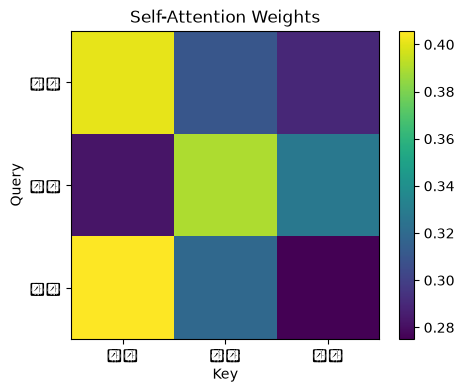

In [48]:
weights_np = weights.detach().cpu().numpy()

plt.figure(figsize=(5, 4))
plt.imshow(weights_np)
plt.xticks(range(len(token)), token)
plt.yticks(range(len(token)), token)
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Self-Attention Weights")
plt.colorbar()
plt.show()

### 2. Transformer Encoder 흐름

```
문장 > Tokenization > Token ID > Token Embedding + Positional Encoding >
Multi-Head Self-Attention > Residual Connection + LayerNorm >
Feed Forward Network(FFN) > Residual Connection + LayerNorm > Encoder 출력
```

# **Token ID 만들기**

In [49]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(2026)
torch.set_printoptions(precision=3, sci_mode=False)

vocab = {"<PAD>":0, "커피":1, "한잔":2, "어때":3}
tokens = ["커피", "한잔", "어때"]
token_ids = torch.tensor([[1, 2, 3]])

print(tokens)
print(token_ids)
print("shape:", token_ids.shape)

['커피', '한잔', '어때']
tensor([[1, 2, 3]])
shape: torch.Size([1, 3])


### Embedding
정수ID를 nn.Embdding에 넣어 d_model 차원의 실수 벡터로 바꿈
```
d_model=8
커피 > 1 > [8개의 실수]
한잔 > 2 > [8개의 실수]
어때 > 3 > [8개의 실수]
```
> 입력 shape는 (batch, sequence_length)이고, Embedding후에는 (batch, sequence_length, d_model)

In [50]:
vocab_size = len(vocab)
d_model = 8

embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
X = embedding(token_ids)

print(X)
print("shape:", X.shape)  # (batch, sequence_length, d_model)

tensor([[[-0.545,  0.219, -1.496,  0.343, -0.192, -0.903,  0.998,  0.036],
         [ 0.244,  0.073,  0.900, -0.805, -0.531,  1.579,  1.451, -1.079],
         [-2.191,  1.543, -0.777,  2.194,  0.926,  0.685, -0.603,  0.600]]],
       grad_fn=<EmbeddingBackward0>)
shape: torch.Size([1, 3, 8])


### Positional Encoding: 순서 정보 넣기
- Self-Attention은 모든 토큰의 관계를 한 번에 계산하므로 RNN처럼 처리 순서 자체에서 위치 정보를 엊지 않음
- 입력에 위치 정보를 따로 넣어줌
- Transformer 논문은 고정된 Sin/Cos Positional Encoding을 사용
    - Transformer 입력 = Token Embedding + Positional Encoding

```
커피 Embdding [0.20, -0.40, 0.70, ...]
0번 위치 Position [0.00, 1.00, 0.00, ...]
최종 입력 [0.20, 0.60, 0.70, ...]
```

> 모델이 각 숫자를 "단어 값"과 "위치 값"으로 따로 분리해 읽는 것은 아님. 같은 d_model 공간에서 두 정보를 더해 토큰의 의미 + 위치가 함께 들어있는 표현을 만드는 것

> 예) "나는 강아지를 좋아해"와 "강아지는 나를 좋아해"처럼 같은 단어가 등장해도 위치와 관계가 달라지면 의미가 달라질 수 있으므로 위치 정보가 중요

### Sin/Cos을 사용하는 이유
- 각 위치마다 여러 주기의 Sin/Cos 값을 조합하여 서로 다른 패텅을 만듦
- 값은 학습으로 바꾸는 파라미터가 아니라 공식으로 게산한 고정값
- 위치 정보를 입력 임베딩에 단순히 더하지 않음
- 절대적인 위치

### RoPE
- Attention을 계산할 때 사용하는 Q와 K에 위치 정보를 반영
- 토큰 위치에 따라서 Q와 K 벡터를 조금씩 회전시키는 방법
- 상대적인 위치 관계

In [51]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        # torch.arange(0, 100)
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)

        # torch.arange(0, d_model, 2): 0, 2, 4, ... 짝수 차원의 인덱스
        # 각 차원마다 서로 다른 주기의 sin/cos을 만들기 위해
        # 논문의 10000^(2i/d_model) 형태 exp()로 계산하기 편하게 바꾼 것
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # 학습 파라미터가 아닌 고정 텐서이므로 buffer로 등록
        # pe는 공식으로 미리 계산해 놓은 고정값
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

pos_encoding = PositionalEncoding(d_model)
X_pos = pos_encoding(X)

print("Embedding:", X.shape)
print("Position 추가:", X_pos.shape)
print(X_pos)

Embedding: torch.Size([1, 3, 8])
Position 추가: torch.Size([1, 3, 8])
tensor([[[-0.545,  1.219, -1.496,  1.343, -0.192,  0.097,  0.998,  1.036],
         [ 1.085,  0.614,  1.000,  0.190, -0.521,  2.579,  1.452, -0.079],
         [-1.282,  1.127, -0.578,  3.174,  0.946,  1.685, -0.601,  1.600]]],
       grad_fn=<AddBackward0>)


### Multi-Head Self-Attention
- 위치 정보가 더해진 X_pos를 Query, Key, Value 모두에 넣어줌
```
query = X_pos
key = 
```

![멀티헤드어텐션](./images/멀티헤드어텐션1.png)
![멀티헤드어텐션](./images/멀티헤드어텐션2.png)
![멀티헤드어텐션](./images/멀티헤드어텐션3.png)
![멀티헤드어텐션](./images/멀티헤드어텐션4.png)

In [52]:
num_heads = 2

mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=num_heads,
    batch_first=True
)

attn_out, attn_weights = mha(
    query=X_pos, key=X_pos, value=X_pos,
    need_weights=True,
    average_attn_weights=False
)

print("입력:", X_pos.shape)
print("출력:", attn_out.shape)
print("Head별 Weight:", attn_weights.shape)

입력: torch.Size([1, 3, 8])
출력: torch.Size([1, 3, 8])
Head별 Weight: torch.Size([1, 2, 3, 3])


### Residual Connection(Skip Connection)
- Attention 결과만 다음 층으로 보내지 않고 원래 입력을 다시 더함
```
y = x + F(x)
```

- x: Attention에 들어가기 전 원래 정보
- F(x): Attention이 계산한 변화 정보
- x + F(x): 원래 정보를 유지하면서 새 정보를 추가한 결과

In [53]:
residual = X_pos + attn_out
print(residual.shape)

torch.Size([1, 3, 8])


In [54]:
x_original = X_pos[0, 0]
attention_change = attn_out[0, 0]
x_after_residual = x_original + attention_change

print("원래 입력 x        :", x_original)
print("Attention 결과 F(x):", attention_change)
print("Residual x + F(x)  :", x_after_residual)

# shape가 같아야 원소별 덧셈이 가능합니다.
print("x shape    :", x_original.shape)
print("F(x) shape :", attention_change.shape)

원래 입력 x        : tensor([-0.545,  1.219, -1.496,  1.343, -0.192,  0.097,  0.998,  1.036],
       grad_fn=<SelectBackward0>)
Attention 결과 F(x): tensor([-0.497, -0.147,  0.130,  0.086, -0.147, -0.007, -0.149,  0.629],
       grad_fn=<SelectBackward0>)
Residual x + F(x)  : tensor([-1.042,  1.072, -1.365,  1.429, -0.339,  0.090,  0.849,  1.665],
       grad_fn=<AddBackward0>)
x shape    : torch.Size([8])
F(x) shape : torch.Size([8])


### Layer Normaliztion
- Layernorm은 각 토큰 벡터의 feature 차원을 기준으로 값을 정규화
- 현재 shape가 (batch, seq_len, d_model)이라면 nn.LayerNorm(d_model)은 각 (d_model,)벡터를 독립적으로 정규화
- 예) 커피가 8개의 숫자로 표현된다면 그 8개 값의 편균과 분산을 이용해 정규화
- BatchNorm과 달리 배치 크기에 크게 의존하지 않아 Transformer에 잘 학습됨

In [55]:
norm1 = nn.LayerNorm(d_model)
x1 = norm1(residual)

print("전:", residual[0,0])
print("후:", x1[0,0])
print("평균:", x1[0,0].mean())
print("분산:", x1[0,0].var(unbiased=False))

전: tensor([-1.042,  1.072, -1.365,  1.429, -0.339,  0.090,  0.849,  1.665],
       grad_fn=<SelectBackward0>)
후: tensor([-1.256,  0.730, -1.560,  1.066, -0.595, -0.193,  0.520,  1.288],
       grad_fn=<SelectBackward0>)
평균: tensor(0.000, grad_fn=<MeanBackward0>)
분산: tensor(1.000, grad_fn=<VarBackward0>)


### Feed Forward Network(FFN)
- Attention: 토큰과 토큰 사이에 어떤 정보를 가져올지 계산
- FFN: Attention으로 모은 정보를 각 토큰 위치별로 독립적으로 비선형 변환

In [56]:
ffn = nn.Sequential(
    nn.Linear(d_model, 32),
    nn.ReLU(),
    nn.Linear(32, d_model)
)

ffn_out = ffn(x1)
print("입력:", x1.shape)
print("출력:", ffn_out.shape)

입력: torch.Size([1, 3, 8])
출력: torch.Size([1, 3, 8])


### 두 번째 Residual + Layer Normaliztion
- Encoder Block에는 두 개의 서브레이어가 있고 각각 Residual연결이 붙음
    - Self-Attentionm > Residual > LayerNorm
    - FFN > Residual > LayerNorm

In [57]:
norm2 = nn.LayerNorm(d_model)
encoder_output = norm2(x1 + ffn_out)
print(encoder_output)
print(encoder_output.shape)

tensor([[[-1.192,  0.787, -1.456,  1.027, -1.070,  0.099,  0.867,  0.937],
         [-0.302, -0.276, -0.002, -0.457, -1.390,  2.246,  0.652, -0.471],
         [-1.626,  0.182, -0.915,  1.775, -0.432,  0.766, -0.389,  0.638]]],
       grad_fn=<NativeLayerNormBackward0>)
torch.Size([1, 3, 8])


### Encoder에서 Padding Mask 사용
- 배치 안의 문장 길이를 맞추기 위해 \<PAD\>를 넣음
```
커피 한잔 어때
커피 어때 <PAD>
```
- PAD는 실제 문장 내용이 아니므로 Attention의 Key/Value 참고 대상에서 제외


In [58]:
padded_ids = torch.tensor([
    [1, 2, 3],
    [1, 3, 0]
])

padding_mask = padded_ids.eq(0)

print(padded_ids)
print(padding_mask)
# False = 실제 토큰
# True  = PAD

tensor([[1, 2, 3],
        [1, 3, 0]])
tensor([[False, False, False],
        [False, False,  True]])


In [59]:
padded_x = pos_encoding(embedding(padded_ids))

# key_padding_mask: key위치는 참고 대상에서 제외
masked_out, masked_weights = mha(
    padded_x, padded_x, padded_x,
    key_padding_mask=padding_mask,
    need_weights=True
)

print(masked_weights)
print("\n두 번째 문장:")
print(masked_weights[1])

tensor([[[0.277, 0.322, 0.401],
         [0.377, 0.205, 0.418],
         [0.286, 0.299, 0.414]],

        [[0.392, 0.608, 0.000],
         [0.372, 0.628, 0.000],
         [0.414, 0.586, 0.000]]], grad_fn=<MeanBackward1>)

두 번째 문장:
tensor([[0.392, 0.608, 0.000],
        [0.372, 0.628, 0.000],
        [0.414, 0.586, 0.000]], grad_fn=<SelectBackward0>)


### Causal Mask
- Padding Mask: 의미 없는 \<PAD\> 위치를 가림
- Causal Mask: 현재 위치보다 뒤에 있는 미래 토큰을 가림
```
"나는 커피를 마신다" 한 번에 입력해 학습되더라도 각 위치가 볼 수 있는 범위는 아래와 같음
Query   Key     나는    커피를      마신다
나는              O       X          X
커피를            O       O          X  
마신다            O       O          O
```

> 추론하 떄는 실제로 한 토큰씩 생성. 하지만 학습할 떄는 정답

In [60]:
seq_len = 4

causal_mask = torch.triu(
    torch.ones(seq_len, seq_len, dtype=torch.bool),
    diagonal=1
)

print(causal_mask)

tensor([[False,  True,  True,  True],
        [False, False,  True,  True],
        [False, False, False,  True],
        [False, False, False, False]])


In [61]:
demo_x = torch.randn(1, seq_len, d_model)
causal_mha = nn.MultiheadAttention(d_model, num_heads=2, batch_first=True)

_, causal_weights = causal_mha(
    demo_x, demo_x, demo_x,
    attn_mask=causal_mask,
    need_weights=True
)

print("Causal Attention Weights:")
print(causal_weights[0])
print("\n미래 위치(오른쪽 위 삼각형)의 가중치가 0인지 확인하세요.")

Causal Attention Weights:
tensor([[1.000, 0.000, 0.000, 0.000],
        [0.640, 0.360, 0.000, 0.000],
        [0.315, 0.311, 0.374, 0.000],
        [0.166, 0.159, 0.303, 0.372]], grad_fn=<SelectBackward0>)

미래 위치(오른쪽 위 삼각형)의 가중치가 0인지 확인하세요.


### Encoder Block 구현

In [62]:
class SimpleTransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=8, num_heads=2, d_ff=32, dropout=0.1):
        super().__init__()

        self.self_attention = nn.MultiheadAttention(
            d_model, num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        attn_out, weights = self.self_attention(
            x, x, x,
            key_padding_mask=padding_mask,
            need_weights=True
        )

        x = self.norm1(x + self.dropout1(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))

        return x, weights

block = SimpleTransformerEncoderBlock()
out, weights = block(X_pos)

print("입력:", X_pos.shape)
print("출력:", out.shape)
print("Weight:", weights.shape)

입력: torch.Size([1, 3, 8])
출력: torch.Size([1, 3, 8])
Weight: torch.Size([1, 3, 3])


### 3. Decorder
- Encoder: 입력 토큰 전체를 Self-Attention으로 처리하여 문맥이 반영된 표현을 만듦
- Decoder: 출력 문장을 생성.
    - Masked Self-Attention: Decoder가 미래 출력 토큰을 미리 보지 못하게 함.
    - Cross-Attention: Decoder가 Encoder 출력의 어느 부분을 참고할지 계산.

    ```
        Q = Decoder의 현재 표현
        K = Encoder 출력
        V = Encoder 출력

        입력 > Encoder > Encoder Memory > 출력 입력 > Masked Self-Attention > Cross-Attention > FFN > Decoder > 출력
    ```

> GPT 같은 decoder-only 모델에는 별도의 Encoder와 Cross-Attention이 없는 일반적인 구성이 사용

In [63]:
cross_attention = nn.MultiheadAttention(
    embed_dim=8,
    num_heads=2,
    batch_first=True
)

encoder_memory = torch.randn(1, 5, 8)
decoder_state = torch.randn(1, 3, 8)

cross_out, cross_weights = cross_attention(
    query=decoder_state,
    key=encoder_memory,
    value=encoder_memory
)

print("Q(Decoder):", decoder_state.shape)
print("K/V(Encoder):", encoder_memory.shape)
print("출력:", cross_out.shape)
print("Weight:", cross_weights.shape)

Q(Decoder): torch.Size([1, 3, 8])
K/V(Encoder): torch.Size([1, 5, 8])
출력: torch.Size([1, 3, 8])
Weight: torch.Size([1, 3, 5])


![트랜스포머](./images/트렌스포머.png)